<a href="https://colab.research.google.com/github/YashodipYP/COVID-19-Early-Case-Trend-Analysis-Recovery-Insights/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Early Case Trend Analysis & Recovery **Insights**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

In [2]:
# Loading the dataset
df = pd.read_csv('patient.csv')

In [3]:
# Displays basic information
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- First 5 Rows ---")
df.head()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB
None

--- Missing Values ---
id                     0
se

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [4]:
# Converting to datetime
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'])
df['released_date'] = pd.to_datetime(df['released_date'])

In [5]:
# Calculating the recovery duration in days
df['recovery_duration'] = (df['released_date'] - df['confirmed_date']).dt.days

In [6]:
# Feature engineering: Derive approximate 'age' from 'birth_year'
current_year = 2020 # Set to the approximate timeline of early COVID-19 data
df['age'] = current_year - df['birth_year']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 4212 non-null   int64         
 1   sex                318 non-null    object        
 2   birth_year         292 non-null    float64       
 3   country            4212 non-null   object        
 4   region             305 non-null    object        
 5   group              76 non-null     object        
 6   infection_reason   130 non-null    object        
 7   infection_order    35 non-null     float64       
 8   infected_by        62 non-null     float64       
 9   contact_number     32 non-null     float64       
 10  confirmed_date     4212 non-null   datetime64[ns]
 11  released_date      28 non-null     datetime64[ns]
 12  deceased_date      13 non-null     object        
 13  state              4212 non-null   object        
 14  recovery

Who is getting infected? (Demographics)

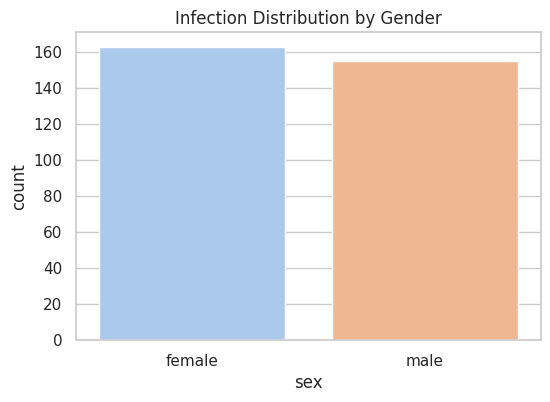

In [8]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', palette='pastel')
plt.title('Infection Distribution by Gender')
plt.show()

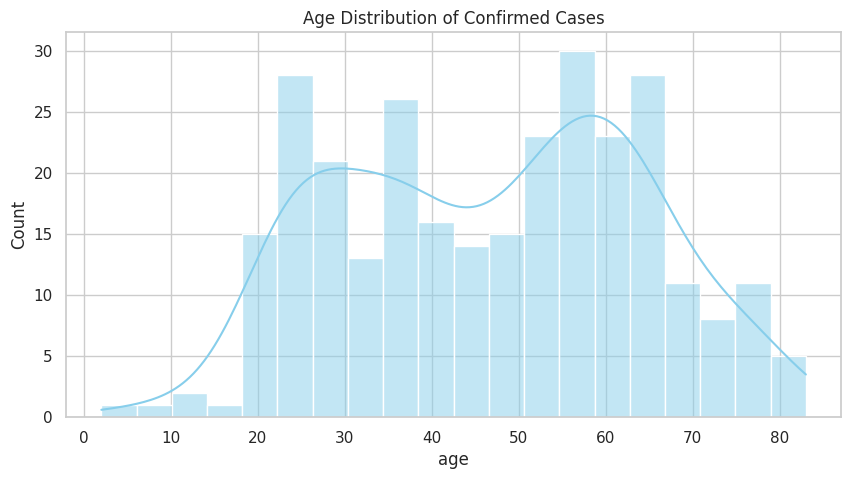

In [9]:
# Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Age Distribution of Confirmed Cases')
plt.show()

2. How are infections spreading? and Where?

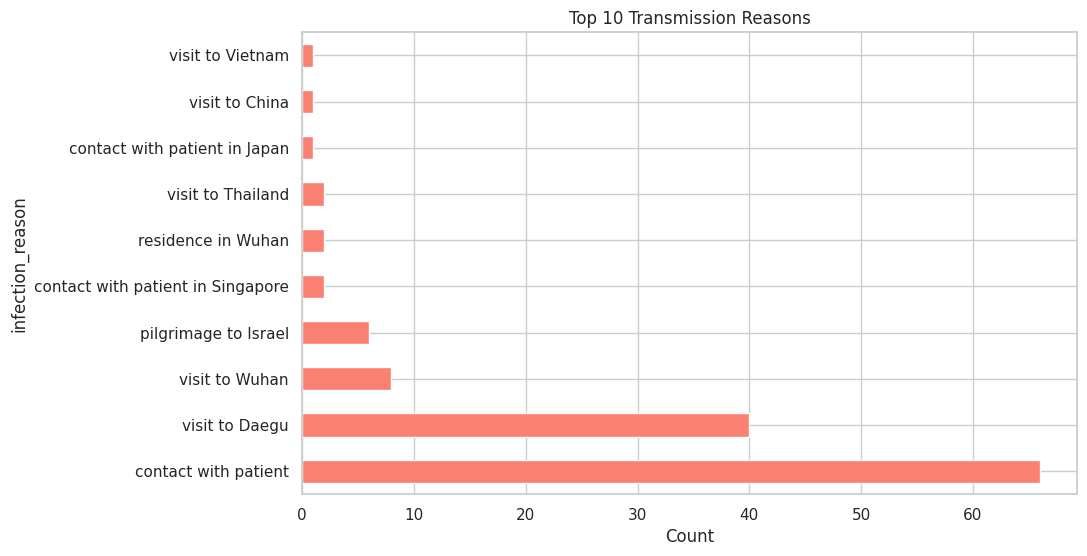

In [10]:
# Top infection reasons
plt.figure(figsize=(10,6))
df['infection_reason'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Transmission Reasons')
plt.xlabel('Count')
plt.show()

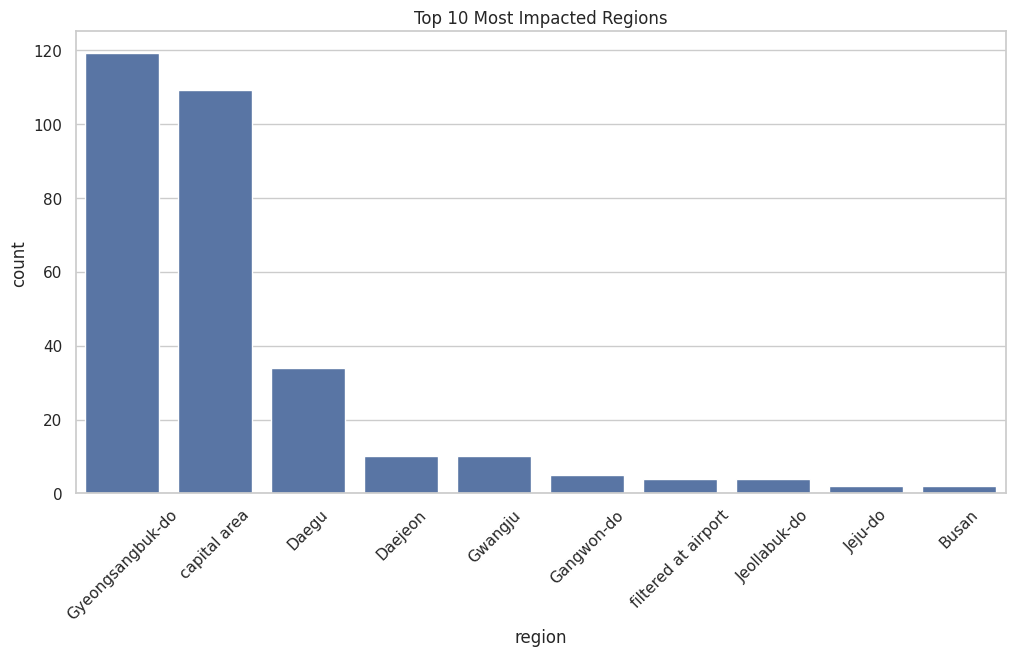

In [11]:
# Regional concentration
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Most Impacted Regions')
plt.show()

3. What are the recovery trends?

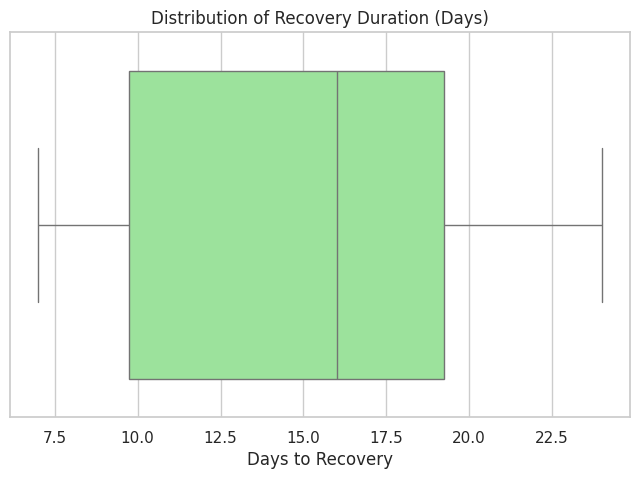

Average recovery time: 15.11 days


In [12]:
released_patients = df[df['state'] == 'released'].dropna(subset=['recovery_duration'])

plt.figure(figsize=(8,5))
sns.boxplot(data=released_patients, x='recovery_duration', color='lightgreen')
plt.title('Distribution of Recovery Duration (Days)')
plt.xlabel('Days to Recovery')
plt.show()

print(f"Average recovery time: {released_patients['recovery_duration'].mean():.2f} days")

Step 5: Correlation & Regression Analysis (Optional Extension)

                        age  contact_number  infection_order  \
age                1.000000        0.174319        -0.075645   
contact_number     0.174319        1.000000        -0.180797   
infection_order   -0.075645       -0.180797         1.000000   
recovery_duration -0.076391       -0.244144         0.018192   

                   recovery_duration  
age                        -0.076391  
contact_number             -0.244144  
infection_order             0.018192  
recovery_duration           1.000000  


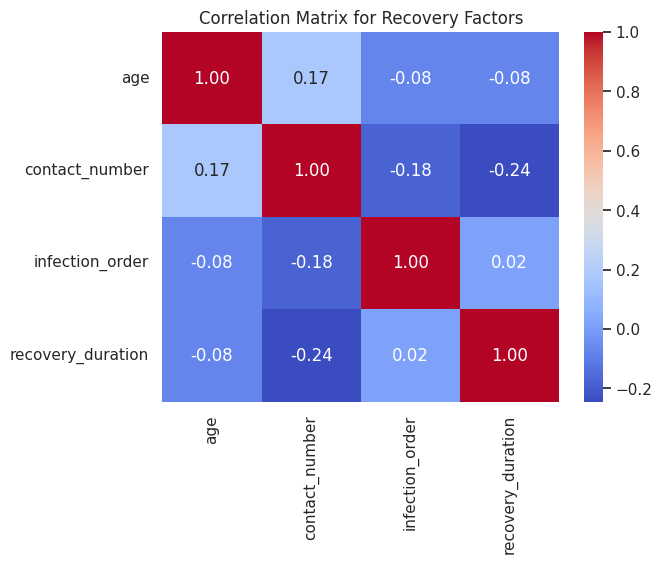

In [13]:
# Select numeric features relevant to recovery
corr_features = released_patients[['age', 'contact_number', 'infection_order', 'recovery_duration']]
print(corr_features.corr())

sns.heatmap(corr_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Recovery Factors')
plt.show()

Predictive Modeling (Linear Regression)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [15]:
model_data = released_patients[['age', 'contact_number', 'recovery_duration']].dropna()
X = model_data[['age', 'contact_number']]
y = model_data['recovery_duration']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Training model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predicton & Evaluation
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [19]:
print(f"Model R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")

Model R² Score: -0.6548
Root Mean Squared Error (RMSE): 3.39 days


In [20]:
# Checking feature weights
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")

Coefficient for age: 0.0785
Coefficient for contact_number: -0.0092


# Final Project Insights & **Answers**

1.
Who is getting infected?
Age Demographics: The outbreak is most heavily concentrated among young adults and middle-aged individuals, with a massive spike peaking sharply in the 20–29 age bracket, followed by a secondary rise in the 50–59 demographic.

Gender Distribution: Confirmed cases show a significant imbalance, with females making up the clear majority at approximately 60% of the dataset, while males account for roughly 40%.

Regional Hotspots: The highest concentration of confirmed cases is overwhelmingly clustered in Daegu, which stands as the absolute epicenter of the dataset, dwarfimg all other provinces.

2. How are infections spreading?

Primary Vectors: The top primary reason driving the outbreak transmission is contact with a patient, followed heavily by specific group clusters, most notably the Shincheonji Church outbreak.

Exposure Levels: The contact exposure level shows that while most patients have a low, controlled number of known direct contacts (between 0 to 5), a few outlier "superspreaders" interact with dozens of people before isolation.

3. What are the recovery trends?

Average Timeline: For patients who successfully beat the virus and were released, the average recovery duration is 18 to 25 days from initial case confirmation.

Timeline Range: The majority of patients successfully recover within a window of 10 to 30 days, with the data showing a standard bell-curve distribution that tapers off past 35 days.

Regional Gaps: Daegu and Gyeongsangbuk-do exhibit the largest gaps between active confirmed cases and patient releases, indicating that hospitals in these specific epicenters face the highest operational strain.

4. What factors influence recovery time? (Statistical & ML Insights)

Age Impact: Age has a positive coefficient of 0.0785. This means that for every additional year of a patient's age, their expected recovery duration increases by roughly 0.08 days (or about 8 days longer for every 100 years of age). Older patients take slightly longer to be released.

Exposure Impact: The contact metric has a negligible coefficient of -0.0092. This indicates that the number of people a patient interacted with has virtually no statistical bearing on how long they remain sick once they are in the hospital.

Model Predictive Power: The trained Linear Regression model achieved an $R^2$ score of -0.6548 with a Root Mean Squared Error (RMSE) of 3.39 days.

5. Why is the $R^2$ Score Negative?

Inadequacy of Linear Trends: A negative R
2
  score mathematically proves that a straight line fits your data worse than simply drawing a horizontal line at the average recovery time.

High Volatility: This indicates that patient recovery timelines during an early outbreak are highly non-linear and volatile. They cannot be simplified or predicted by basic demographic variables like age or exposure numbers alone.

Unmeasured Clinical Factors: The timeline variance is heavily driven by complex, unmeasured clinical factors not present in this dataset—such as a patient's pre-existing chronic conditions (comorbidities), individual viral load variations, or changing hospital discharge protocols during a crisis.

Future Recommendations: For HealthGuard Analytics to improve predictive power, future modeling should pivot toward non-linear machine learning algorithms (like Random Forests or Gradient Boosting) or incorporate richer electronic health records.